In [1]:
import sqlite3

conn = sqlite3.connect("healthcare_dw.db")
cursor = conn.cursor()

sql_script = """
DROP TABLE IF EXISTS dim_treatment;
DROP TABLE IF EXISTS dim_billing;
DROP TABLE IF EXISTS fact_visits;
DROP TABLE IF EXISTS dim_patients;
DROP TABLE IF EXISTS dim_doctors;

CREATE TABLE dim_doctors (
    doctor_id VARCHAR(20) PRIMARY KEY,
    name VARCHAR(100),
    specialization VARCHAR(100),
    contact BIGINT,
    hospital VARCHAR(100)
);

CREATE TABLE dim_patients (
    patient_id VARCHAR(20) PRIMARY KEY,
    name VARCHAR(100),
    age INT,
    gender VARCHAR(10),
    contact BIGINT,
    address VARCHAR(255)
);

-- Create Fact Table
CREATE TABLE fact_visits (
    Visit_ID TEXT PRIMARY KEY,
    Patient_ID TEXT,
    Doctor_ID TEXT,
    Visit_Date TEXT,
    Visit_Type TEXT,
    Notes TEXT,
    FOREIGN KEY (Doctor_ID) REFERENCES dim_doctors(doctor_id),
    FOREIGN KEY (Patient_ID) REFERENCES dim_patients(patient_id)
);

-- Create Related Tables
CREATE TABLE dim_billing (
    Bill_ID TEXT PRIMARY KEY,
    Visit_ID TEXT,
    Amount DOUBLE,
    Payment_Method TEXT,
    Status TEXT,
    FOREIGN KEY (Visit_ID) REFERENCES fact_visits(Visit_ID)
);

CREATE TABLE dim_treatment (
    Treatment_ID TEXT PRIMARY KEY,
    Visit_ID TEXT,
    Treatment_Type TEXT,
    Medication_Procedure TEXT,
    Outcome TEXT,
    FOREIGN KEY (Visit_ID) REFERENCES fact_visits(Visit_ID)
);
"""

cursor.executescript(sql_script)
conn.commit()
conn.close()

print("Tables created successfully!")

Tables created successfully!


In [2]:
!pip install faker

import pandas as pd
import random
from faker import Faker

fake = Faker()
num_records = 100

# 1. dim_doctors
doctors = [{
    'doctor_id': f'DOC{i:03}',
    'name': fake.name(),
    'specialization': random.choice(['Cardiology', 'Neurology', 'Pediatrics', 'General']),
    'contact': fake.random_number(digits=10),
    'hospital': 'City General Hospital'
} for i in range(1, num_records + 1)]



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.6 MB/s eta 0:00:00


In [3]:
# 2. dim_patients
patients = [{
    'patient_id': f'PAT{i:03}',
    'name': fake.name(),
    'age': random.randint(1, 90),
    'gender': random.choice(['Male', 'Female', 'Other']),
    'contact': fake.random_number(digits=10),
    'address': fake.address().replace('\n', ', ')
} for i in range(1, num_records + 1)]



In [4]:
# 3. fact_visits
visits = [{
    'Visit_ID': f'VIS{i:03}',
    'Patient_ID': random.choice(patients)['patient_id'],
    'Doctor_ID': random.choice(doctors)['doctor_id'],
    'Visit_Date': fake.date_between(start_date='-1y', end_date='today'),
    'Visit_Type': random.choice(['Consultation', 'Follow-up', 'Emergency']),
    'Notes': fake.sentence()
} for i in range(1, num_records + 1)]



In [5]:
# 4. dim_billing
billing = [{
    'Bill_ID': f'BILL{i:03}',
    'Visit_ID': visits[i-1]['Visit_ID'],
    'Amount': round(random.uniform(50.0, 5000.0), 2),
    'Payment_Method': random.choice(['Credit Card', 'Cash', 'Insurance']),
    'Status': random.choice(['Paid', 'Pending'])
} for i in range(1, num_records + 1)]



In [6]:
# 5. dim_treatment
treatment = [{
    'Treatment_ID': f'TRT{i:03}',
    'Visit_ID': visits[i-1]['Visit_ID'],
    'Treatment_Type': random.choice(['Medication', 'Surgery', 'Therapy']),
    'Medication_Procedure': fake.word(),
    'Outcome': random.choice(['Improved', 'Stable', 'Recovered'])
} for i in range(1, num_records + 1)]



In [7]:
# Save all to CSV
pd.DataFrame(doctors).to_csv('dim_doctors.csv', index=False)
pd.DataFrame(patients).to_csv('dim_patients.csv', index=False)
pd.DataFrame(visits).to_csv('fact_visits.csv', index=False)
pd.DataFrame(billing).to_csv('dim_billing.csv', index=False)
pd.DataFrame(treatment).to_csv('dim_treatment.csv', index=False)

print("All 5 CSV files have been created successfully!")

All 5 CSV files have been created successfully!


In [8]:
# ✅ Install required libraries (if needed)
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Load CSV files
patients_df = pd.read_csv('dim_patients.csv')
billing_df = pd.read_csv('dim_billing.csv')
visits_df = pd.read_csv('fact_visits.csv')

sns.set_theme(style="whitegrid")


In [9]:

# ----------------------------------------------------
# ✅ 1. Patient Age Distribution
# ----------------------------------------------------
plt.figure(figsize=(6, 5))
sns.histplot(patients_df['age'], bins=15, kde=True, color='skyblue')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig("patient_age_distribution.png", dpi=300, bbox_inches='tight')
plt.close()



In [10]:
# ----------------------------------------------------
# ✅ 2. Total Revenue by Payment Method
# ----------------------------------------------------
plt.figure(figsize=(6, 5))
revenue_data = billing_df.groupby('Payment_Method')['Amount'].sum().reset_index()
sns.barplot(data=revenue_data, x='Payment_Method', y='Amount', palette='viridis')
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Amount ($)')
plt.savefig("revenue_by_payment_method.png", dpi=300, bbox_inches='tight')
plt.close()



/tmp/ipykernel_7284/1493362130.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_data, x='Payment_Method', y='Amount', palette='viridis')


In [11]:
# ----------------------------------------------------
# ✅ 3. Visit Type Frequency
# ----------------------------------------------------
plt.figure(figsize=(6, 5))
sns.countplot(data=visits_df, x='Visit_Type', palette='magma')
plt.title('Visit Type Frequency')
plt.xlabel('Type of Visit')
plt.ylabel('Number of Visits')
plt.savefig("visit_type_frequency.png", dpi=300, bbox_inches='tight')
plt.close()

print("✅ All images saved successfully as single PNG files in Colab!")

/tmp/ipykernel_7284/3043665482.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=visits_df, x='Visit_Type', palette='magma')


✅ All images saved successfully as single PNG files in Colab!


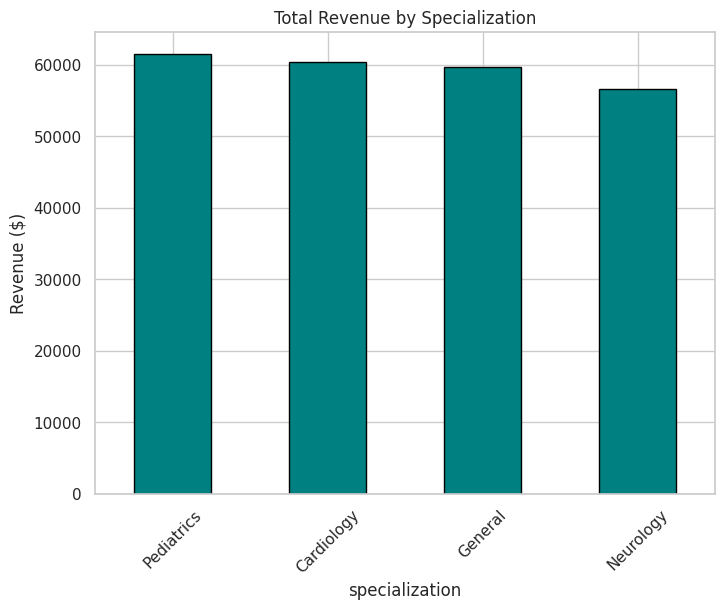

In [12]:


# Load dim_doctors.csv
doctors_df = pd.read_csv('dim_doctors.csv')

# Merge visits_df with doctors_df to get specialization
merged_visits_doctors = pd.merge(visits_df, doctors_df, left_on='Doctor_ID', right_on='doctor_id', how='left')

# Merge with billing_df to get amount
merged_df = pd.merge(merged_visits_doctors, billing_df, on='Visit_ID', how='left')

# =====================================================
# ✅ 4. Revenue by Specialization
# =====================================================
plt.figure(figsize=(8, 6))
spec_revenue = merged_df.groupby('specialization')['Amount'].sum().sort_values(ascending=False)
spec_revenue.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Total Revenue by Specialization')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.savefig("revenue_by_specialization.png", dpi=300, bbox_inches='tight')
plt.show()

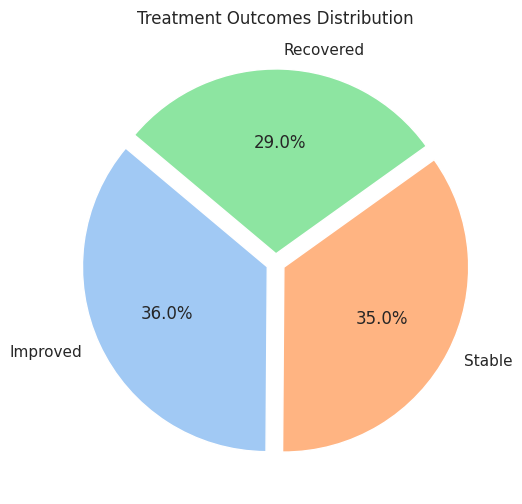

✅ Two separate images saved successfully in Colab!


In [13]:
# =====================================================
# ✅ 5. Treatment Outcome Pie
# =====================================================
import pandas as pd

treatment_df = pd.read_csv('dim_treatment.csv')

plt.figure(figsize=(8, 6))
outcome_counts = treatment_df['Outcome'].value_counts()
plt.pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=140,
    explode=[0.05] * len(outcome_counts)
)
plt.title('Treatment Outcomes Distribution')
plt.savefig("treatment_outcome_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Two separate images saved successfully in Colab!")

In [14]:
import sqlite3
import pandas as pd
# Assume 'doctors', 'patients', 'visits', etc. are already generated in your notebook
# Save to CSV
pd.DataFrame(doctors).to_csv('dim_doctors.csv', index=False)
pd.DataFrame(patients).to_csv('dim_patients.csv', index=False)
pd.DataFrame(visits).to_csv('fact_visits.csv', index=False)
pd.DataFrame(billing).to_csv('dim_billing.csv', index=False)
# Create a fresh database connection
conn = sqlite3.connect('healthcare.db')
# Load FROM CSV into SQL Tables
pd.read_csv('dim_doctors.csv').to_sql('dim_doctors', conn, index=False, if_exists='replace')
pd.read_csv('dim_patients.csv').to_sql('dim_patients', conn, index=False, if_exists='replace')
pd.read_csv('fact_visits.csv').to_sql('fact_visits', conn, index=False, if_exists='replace')
pd.read_csv('dim_billing.csv').to_sql('dim_billing', conn, index=False, if_exists='replace')
pd.read_csv('dim_treatment.csv').to_sql('dim_treatment', conn, index=False, if_exists='replace')

print("Data successfully loaded from CSV into SQL!")

Data successfully loaded from CSV into SQL!


In [15]:
# Check if tables have rows
for table in ['dim_doctors', 'dim_patients', 'fact_visits']:
    count = pd.read_sql_query(f"SELECT COUNT(*) FROM {table}", conn).iloc[0, 0]
    print(f"Table {table} contains {count} records.")

Table dim_doctors contains 100 records.
Table dim_patients contains 100 records.
Table fact_visits contains 100 records.


In [16]:
pd.read_sql_query("""
SELECT
    p.name AS patient_name,
    v.Visit_Type,
    v.Visit_Date
FROM fact_visits v
INNER JOIN dim_patients p
ON v.Patient_ID = p.patient_id
LIMIT 10;
""", conn)

,patient_name,Visit_Type,Visit_Date
0,Denise Diaz,Consultation,2025-04-08
1,William Thomas,Emergency,2025-10-17
2,William Thomas,Follow-up,2025-08-22
3,William Adams,Consultation,2026-02-06
4,Jamie Rose,Follow-up,2026-03-20
5,Mark Morales,Follow-up,2025-06-17
6,Shawna Walker,Consultation,2025-11-03
7,Summer Molina,Emergency,2025-12-16
8,Ryan Wagner,Emergency,2025-11-30
9,Jonathan Patterson,Consultation,2026-01-22


In [17]:
pd.read_sql_query("""
SELECT
    Status,
    COUNT(*) AS bills,
    SUM(Amount) AS total_amount
FROM dim_billing
GROUP BY Status;
""", conn)

,Status,bills,total_amount
0,Paid,53,124925.78
1,Pending,47,113095.58


In [18]:

conn = sqlite3.connect(':memory:')
pd.DataFrame(patients).to_sql('patients_table', conn, index=False, if_exists='replace')

query = "SELECT gender, COUNT(*) as count FROM patients_table GROUP BY gender"


df = pd.read_sql(query, conn)
print(df)

   gender  count
0  Female     36
1    Male     35
2   Other     29


In [19]:
pd.DataFrame(doctors).to_sql('dr_table', conn, index=False, if_exists='replace')
query = """
SELECT specialization, COUNT(*) as Doctor_Count
FROM dr_table
GROUP BY specialization
ORDER BY Doctor_Count DESC;
"""
df_output = pd.read_sql(query, conn)
print(df_output)

  specialization  Doctor_Count
0     Cardiology            31
1     Pediatrics            25
2        General            23
3      Neurology            21
